In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [38]:
%config InlineBackend.figure_format = 'retina'

import random
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from nsppk import NSPPK

from abstractgraph_graphicalizer.chem import draw_molecules as display_graphs

from abstractgraph.operators import *
from abstractgraph.hashing import hash_graph
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_attributed import AttributedConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_batch import  ConditionalAutoregressiveGraphsGenerator
from abstractgraph_generative.edge_generator import (
    EdgeGenerator,
    edge_neighbors,
    make_edge_regression_dataset,
    remove_edges,
)


In [3]:
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)

nbits = 19
feasibility_kwargs = dict(
    nbits=nbits,
    parallel=True,
    backend='loky',
    n_jobs=-1,
)

feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=path(number_of_edges=2),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(combination(number_of_elements=(2, 3), distance=0), cycle(), unlabel()),
        **feasibility_kwargs,
    ),
]

feasibility_estimator = FeasibilityEstimator(feasibility_estimators)

dataset: zinc_250k
size: 290
node_range: [1, 10]
dataset size: 290


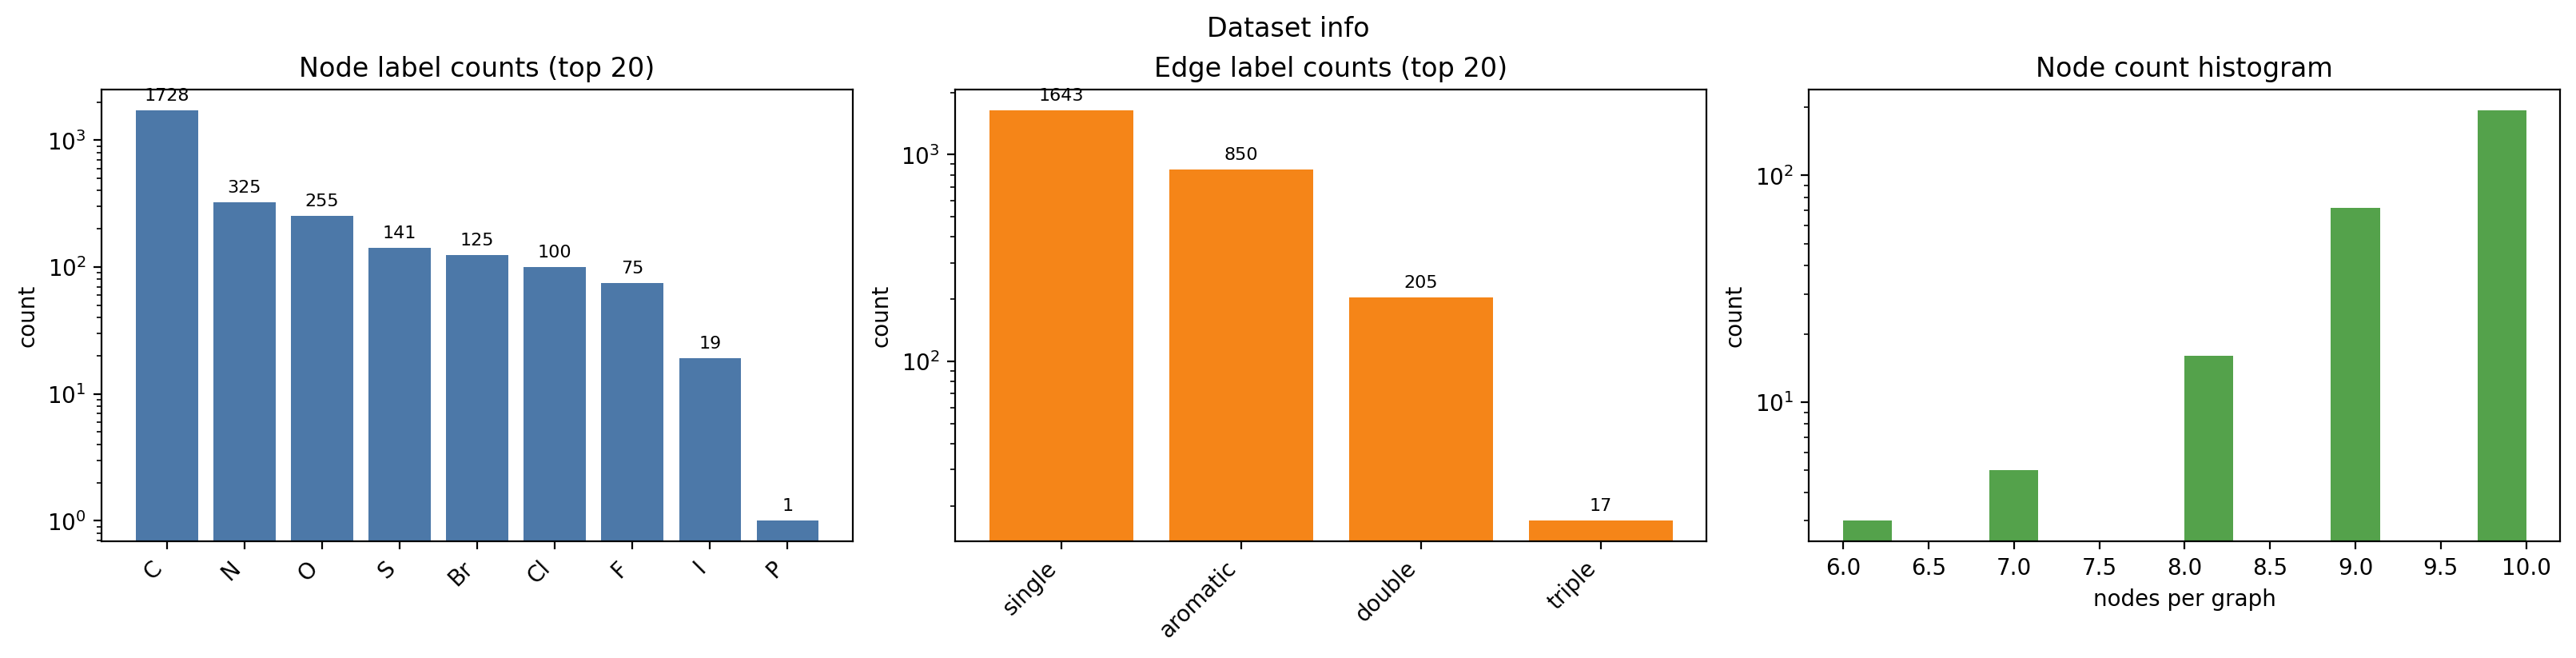

In [30]:
from abstractgraph_graphicalizer.chem import ZINCLoader

loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 2000
min_num_nodes = 1
max_num_nodes = 10

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)
print(f"dataset: {dataset_name}")
print(f"size: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")

from abstractgraph.utils import plot_graph_label_counts
_ = plot_graph_label_counts(graphs, top=20, title='Dataset info', log_scale=True)

# Keep downstream notebook cells unchanged
all_graphs = graphs
all_targets = metadata
print('dataset size:', len(all_graphs))


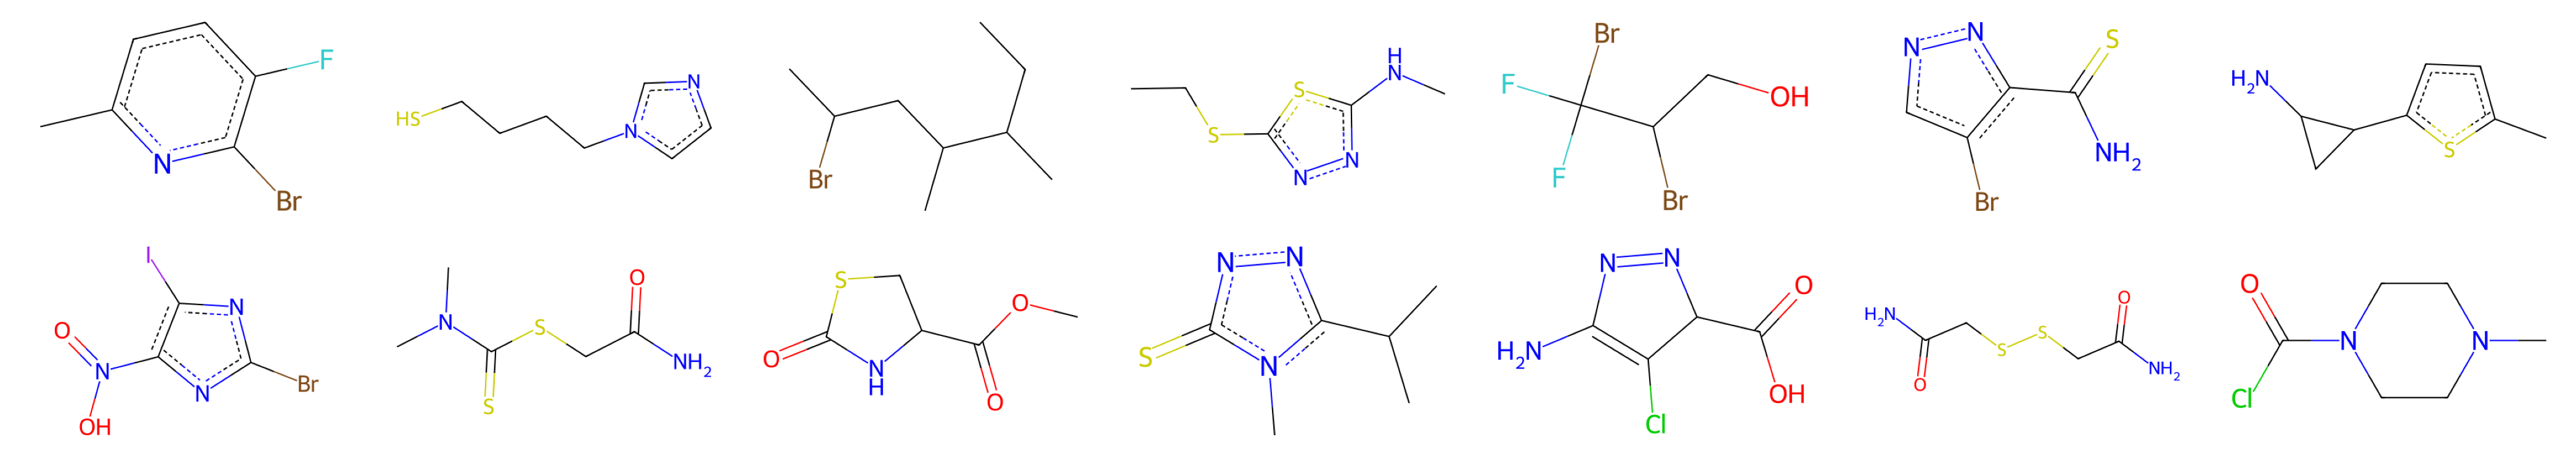

In [31]:
_ = display_graphs(graphs[:7*2], n_graphs_per_line=7)

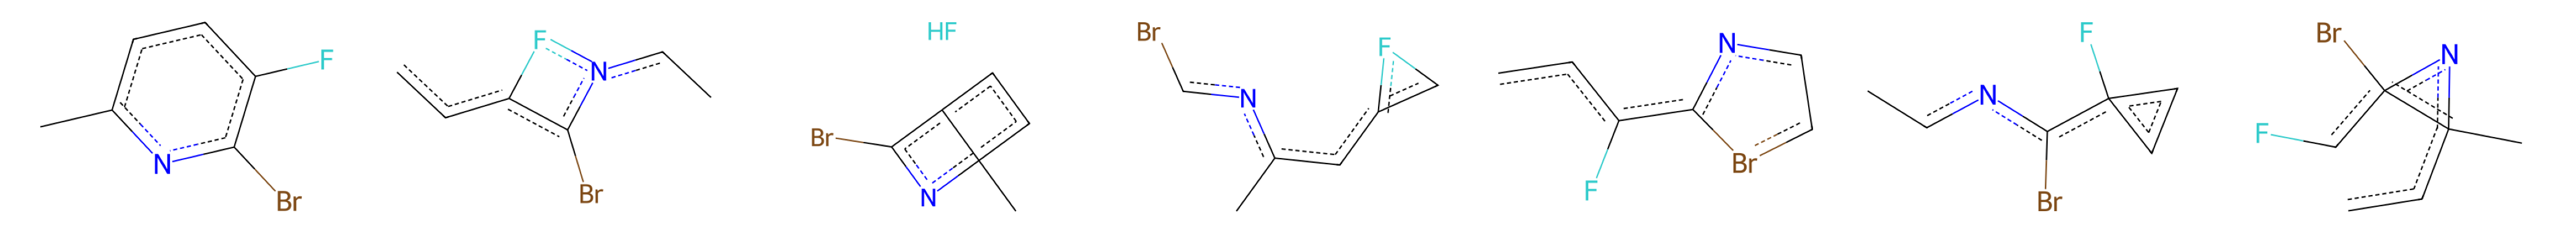

In [32]:
graph= graphs[0]
perturbed_graphs = edge_neighbors(graph, n_samples=6)
_ = display_graphs([graph]+perturbed_graphs, n_graphs_per_line=7)

In [33]:

n_negative_per_positive = 3
positives, negatives, dataset = make_edge_regression_dataset(
    graph,
    n_negative_per_positive=n_negative_per_positive,
    seed=0,
)

print('n_positives =', len(positives))
print('n_negatives =', len(negatives))
print('dataset_size =', len(dataset))
print('n_terminal_positives =', sum(G.number_of_edges() == 0 for G in positives))

n_positives = 9
n_negatives = 24
dataset_size = 33
n_terminal_positives = 1


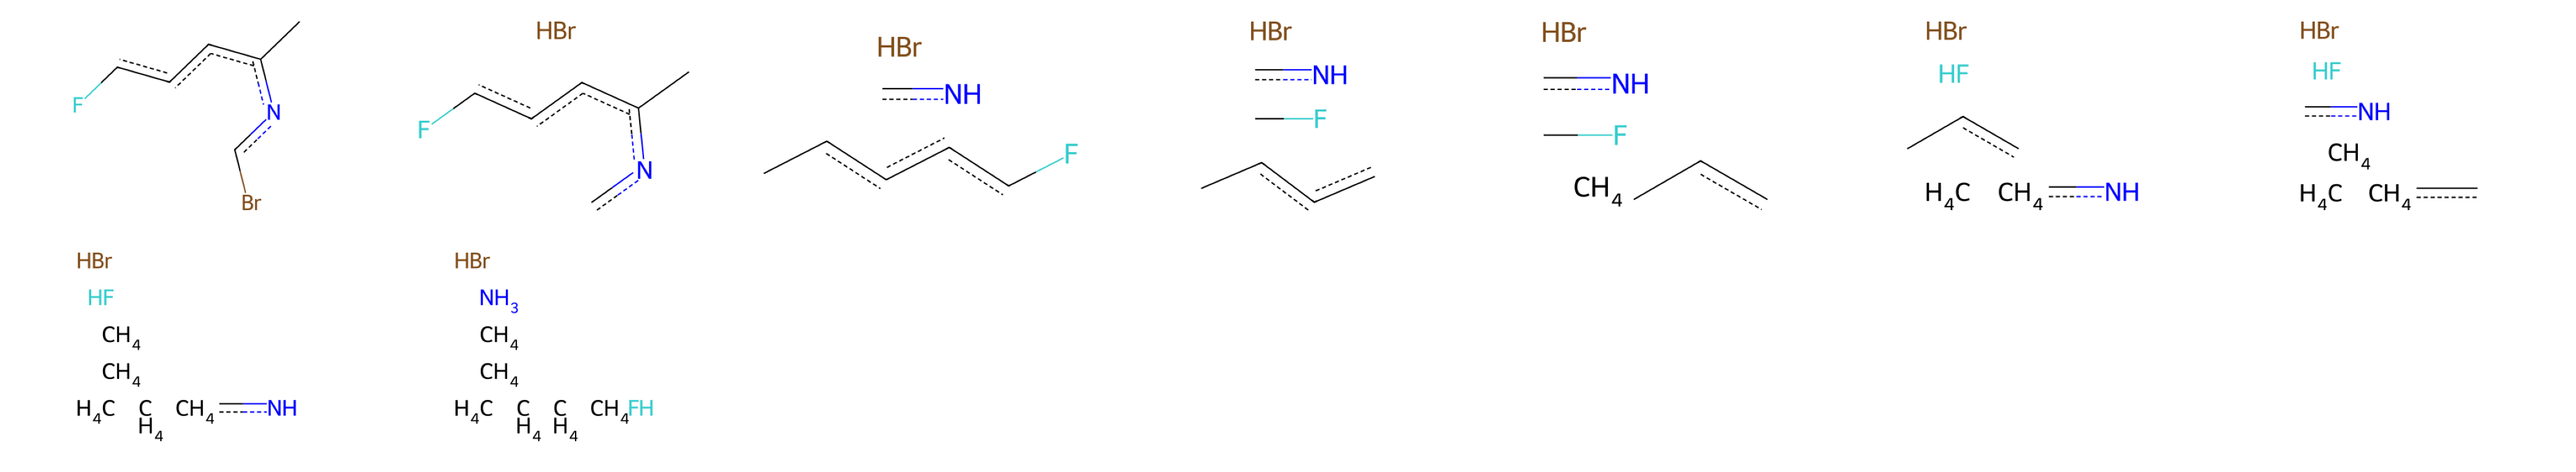

In [34]:
_ = display_graphs(positives[:7*2], n_graphs_per_line=7)

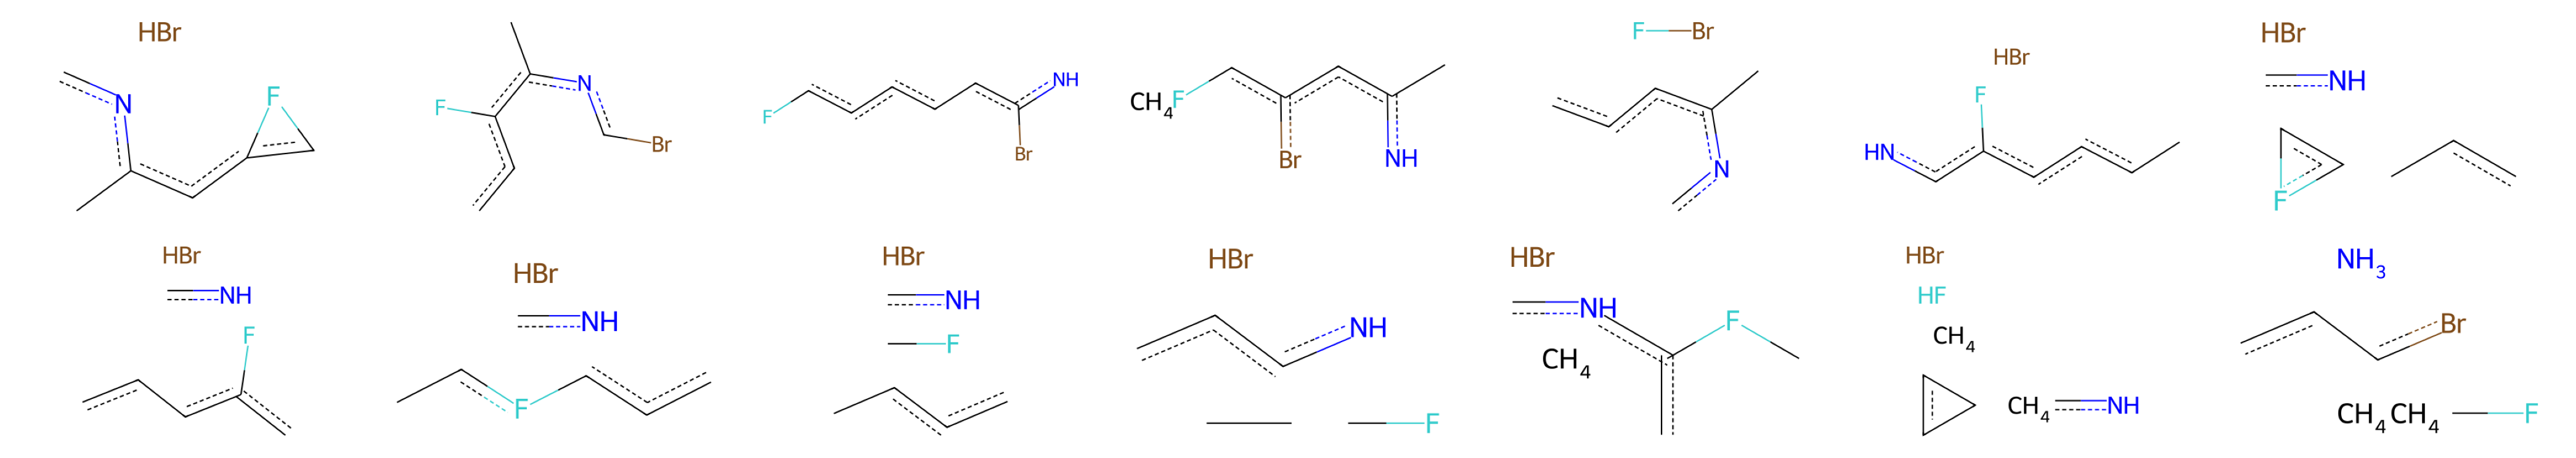

In [35]:
_ = display_graphs(negatives[:7*2], n_graphs_per_line=7)

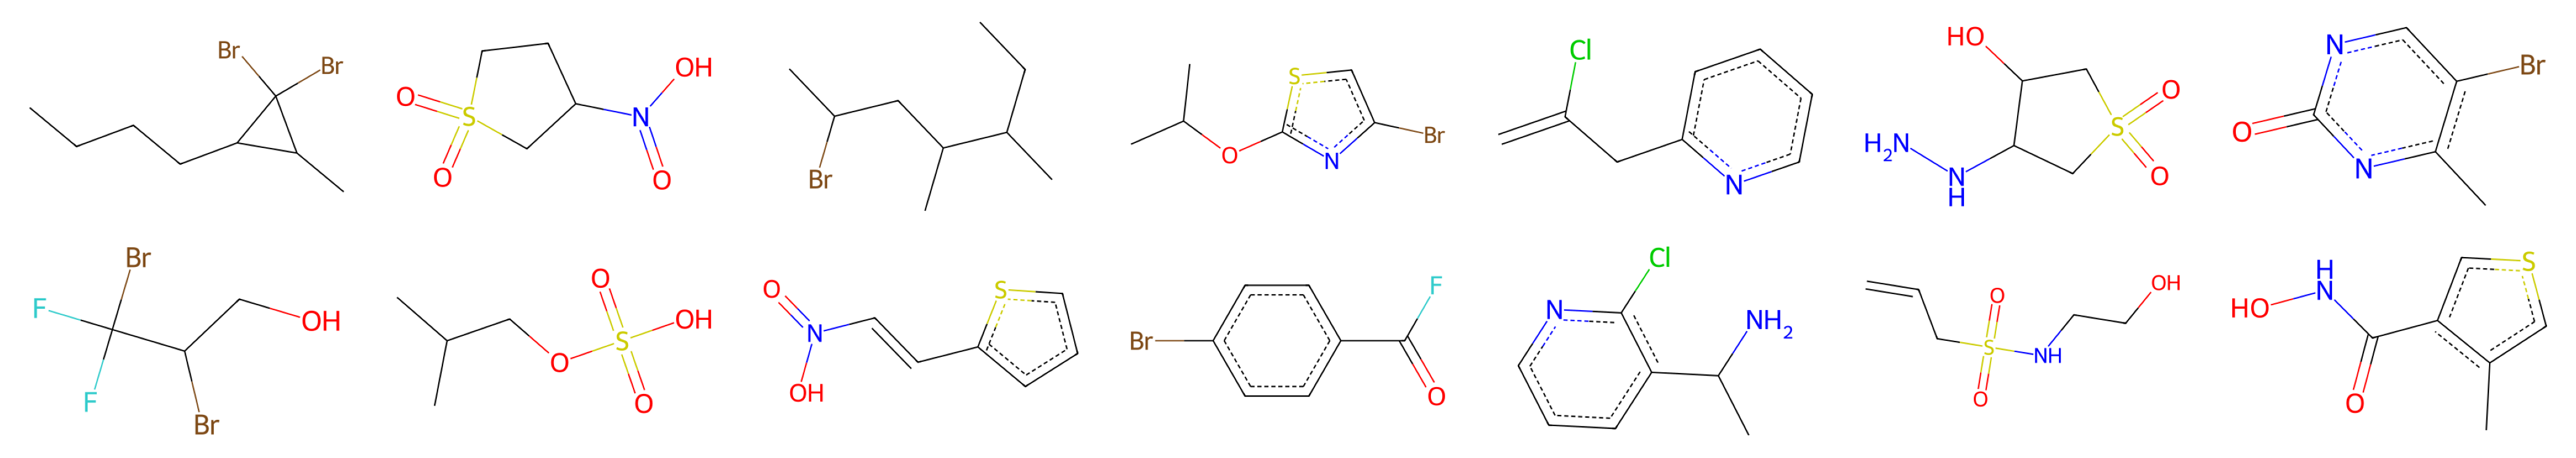

In [36]:
fit_graphs = random.sample(graphs, k=min(7*2, len(graphs)))
_ = display_graphs(fit_graphs, n_graphs_per_line=7)

In [39]:
%%time
USE_NSPPK = True

if USE_NSPPK:
    vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)
else:
    df = add(neighborhood(radius=(1,2)), path(number_of_edges=2))
    vectorizer = AbstractGraphTransformer(
        nbits=14,
        decomposition_function=df,
        return_dense=True,
        n_jobs=-1,
    )

graph_estimator = GraphEstimator(
    transformer=vectorizer,
    estimator=RandomForestClassifier(
        random_state=0, 
        n_estimators=300, 
        n_jobs=-1, 
        class_weight="balanced_subsample",
        ),
)

generator = EdgeGenerator(
    feasibility_estimator,
    graph_estimator,
    n_negative_per_positive=5,
    n_replicates=10,
    beam_size=2,
    fit_n_jobs=-1,
    fit_backend='loky',
    verbose=True,
    seed=0,
).fit(fit_graphs)


[fit] feasibility_graphs=1180 positives=1320 negatives=5900 dataset=7220 time=0m 23.4s
[fit] graph_estimator_graphs=7220 positive_labels=1320 negative_labels=5900 time=7m 0.2s
CPU times: user 45min 21s, sys: 1min 10s, total: 46min 32s
Wall time: 7min 43s


Selecting random graph...


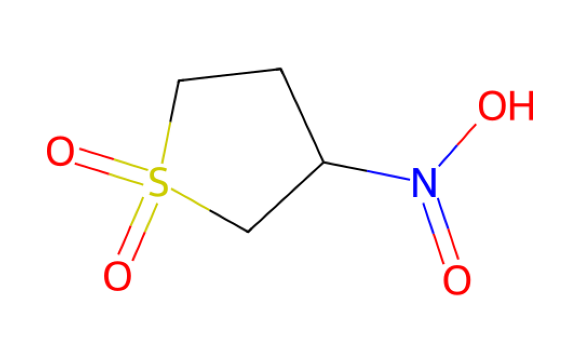

Removed edges to create start graph with target_n_edges = 10


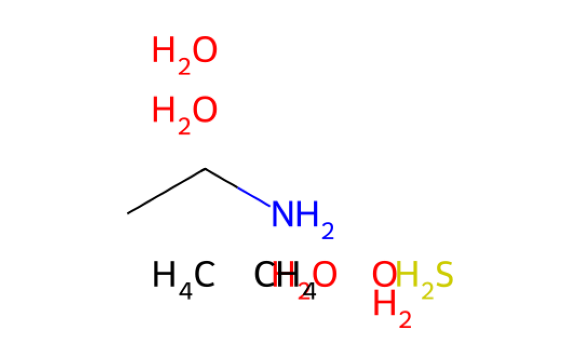

Generating path to target_n_edges = 10
[graph 0] start start_edges=2 target_edges=10 remaining_edges=8


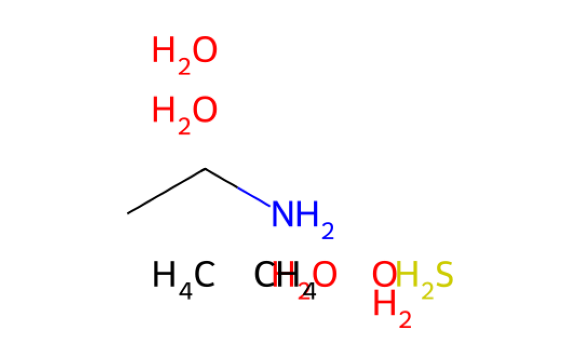

[graph 0] phase=1/4 beam_limit=2 fallback=0/3
[graph 0] phase=1/4 depth=1 beam=1 generated=129 feasible=62 retained=2 tried=129 best_score=0.7222 remaining_edges=7 step_time=1m 48.6s eta=12m 40.5s beam_limit=2


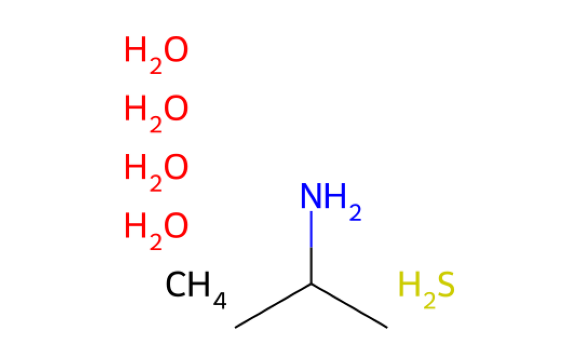

[graph 0] phase=1/4 depth=2 beam=2 generated=252 feasible=96 retained=2 tried=381 best_score=0.7055 remaining_edges=6 step_time=0m 46.0s eta=4m 35.8s beam_limit=2


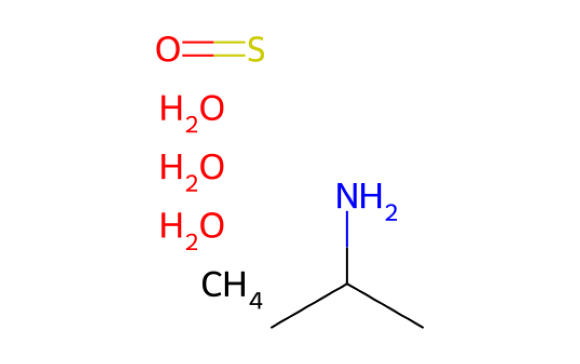

[graph 0] phase=1/4 depth=3 beam=2 generated=246 feasible=70 retained=2 tried=627 best_score=0.7654 remaining_edges=5 step_time=0m 36.3s eta=3m 1.5s beam_limit=2


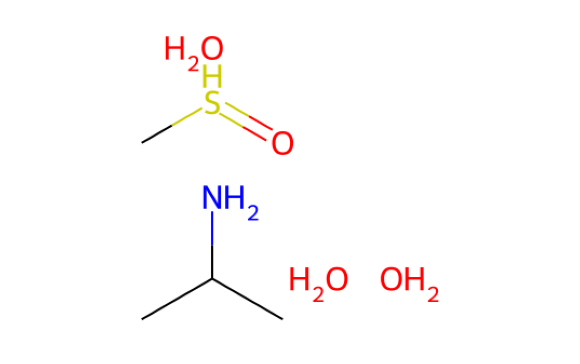

[graph 0] phase=1/4 depth=4 beam=2 generated=240 feasible=43 retained=2 tried=867 best_score=0.6465 remaining_edges=4 step_time=0m 25.3s eta=1m 41.3s beam_limit=2


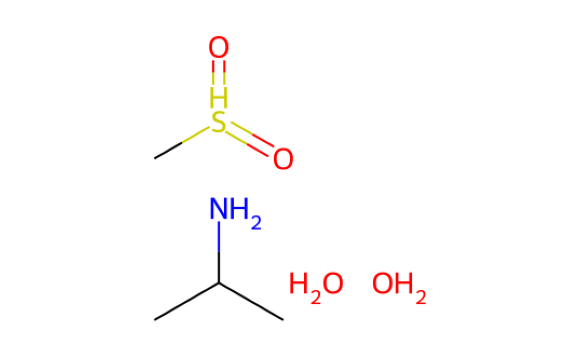

[graph 0] phase=1/4 depth=5 beam=2 generated=234 feasible=32 retained=2 tried=1101 best_score=0.7729 remaining_edges=3 step_time=0m 24.3s eta=1m 12.8s beam_limit=2


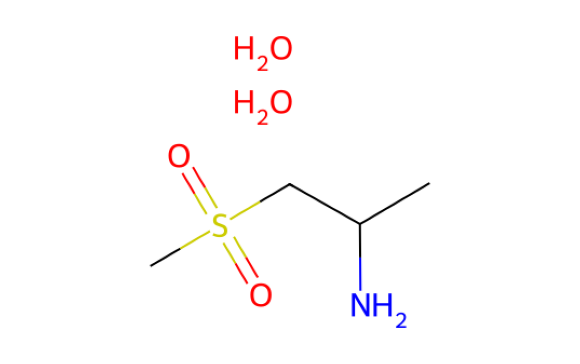

[graph 0] phase=1/4 depth=6 beam=2 generated=228 feasible=20 retained=2 tried=1329 best_score=0.9467 remaining_edges=2 step_time=0m 24.0s eta=0m 48.1s beam_limit=2


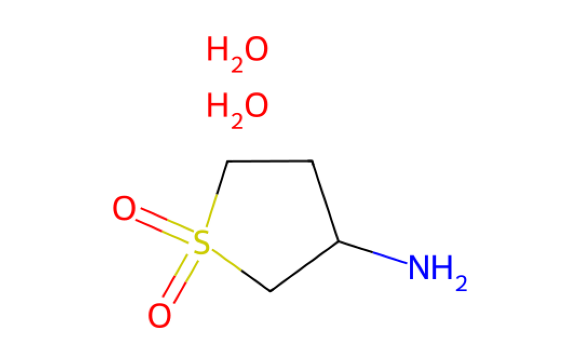

[graph 0] phase=1/4 depth=7 beam=2 generated=222 feasible=9 retained=2 tried=1551 best_score=0.9021 remaining_edges=1 step_time=0m 30.7s eta=0m 30.7s beam_limit=2


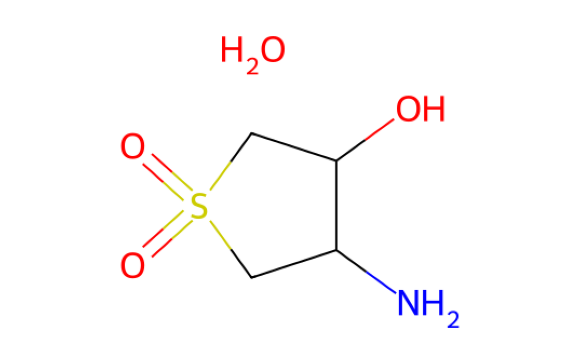

[graph 0] phase=1/4 depth=8 beam=2 generated=216 feasible=4 retained=2 tried=1767 best_score=0.7793 remaining_edges=0 step_time=0m 34.1s eta=0m 0.0s beam_limit=2


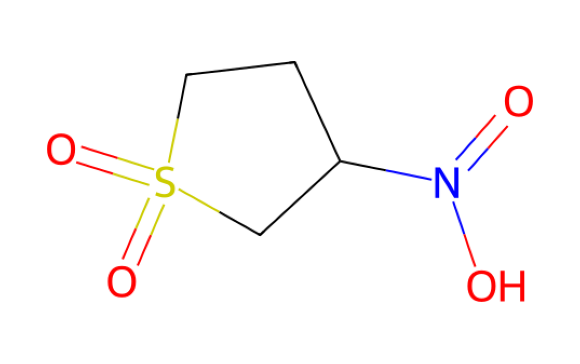

[graph 0] solved phase=1/4 depth=8 max_depth=8 edges=10 remaining_edges=0 tried=1767 elapsed=5m 30.5s eta=0m 0.0s
n_fit_graphs = 14
start_n_edges = 2
target_n_edges = 10
generation_path_length = 9


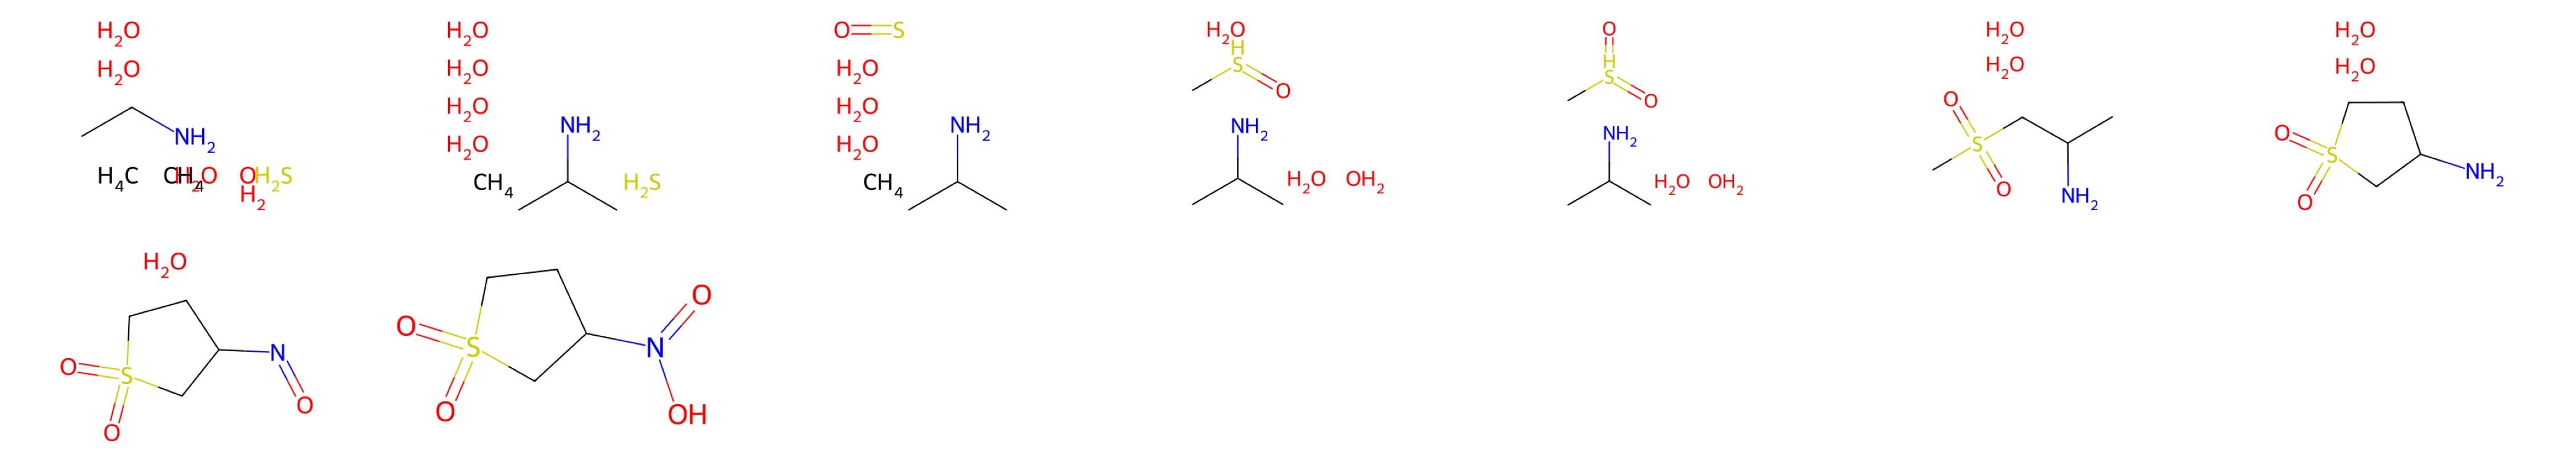

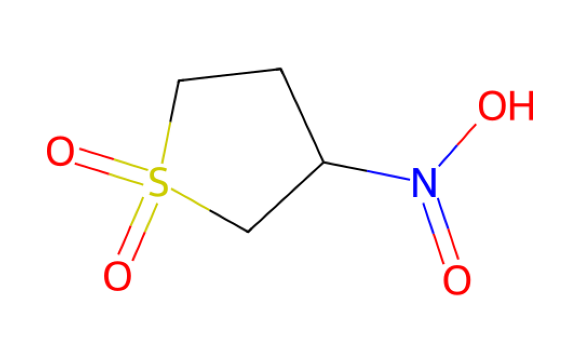

CPU times: user 15.7 s, sys: 6.46 s, total: 22.2 s
Wall time: 5min 32s


In [40]:
%%time
graph = random.choice(fit_graphs)
print('Selecting random graph...')
_ = display_graphs([graph], n_graphs_per_line=1)

start_graph, target_n_edges = remove_edges(graph, size=.8)
print('Removed edges to create start graph with target_n_edges =', target_n_edges)
_ = display_graphs([start_graph], n_graphs_per_line=1)

print('Generating path to target_n_edges =', target_n_edges)
generation_path = generator.generate(
    start_graph,
    n_edges=target_n_edges,
    draw_graphs_fn=lambda graphs: display_graphs(graphs, n_graphs_per_line=1),
)

print('n_fit_graphs =', len(fit_graphs))
print('start_n_edges =', start_graph.number_of_edges())
print('target_n_edges =', target_n_edges)
print('generation_path_length =', len(generation_path))
_ = display_graphs(generation_path, n_graphs_per_line=min(len(generation_path), 7))
_ = display_graphs([graph], n_graphs_per_line=1)


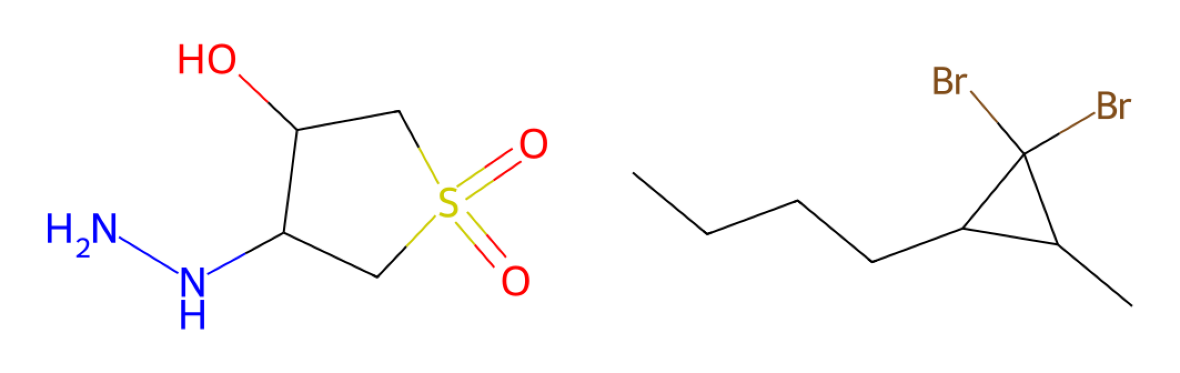

mixed_target_n_edges = 10


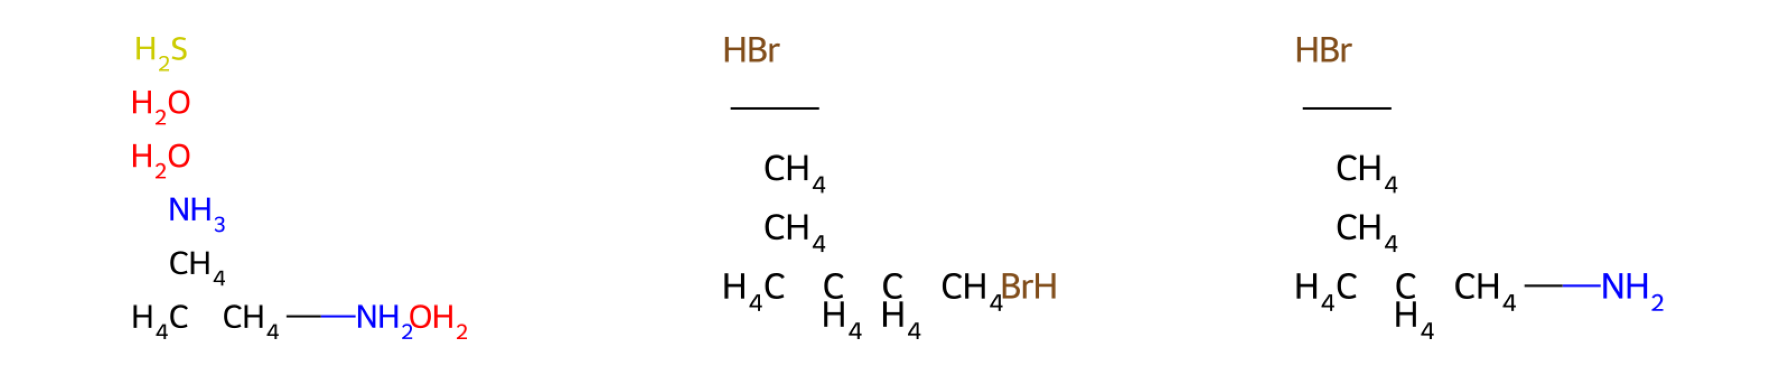

In [49]:
from abstractgraph_generative.edge_generator import mix_connected_components
graph_a, graph_b = random.choice(fit_graphs), random.choice(fit_graphs)
_ = display_graphs([graph_a, graph_b], n_graphs_per_line=2)
start_graph_a, target_n_edges_a = remove_edges(graph_a, size=.9)
start_graph_b, target_n_edges_b = remove_edges(graph_b, size=.9)
mixed_graph = mix_connected_components(start_graph_a, start_graph_b, seed=0)
mixed_target_n_edges = int(np.mean([target_n_edges_a, target_n_edges_b]))
print(f'mixed_target_n_edges = {mixed_target_n_edges}')
_ = display_graphs([start_graph_a, start_graph_b, mixed_graph], n_graphs_per_line=3)

[graph 0] start start_edges=2 target_edges=10 remaining_edges=8


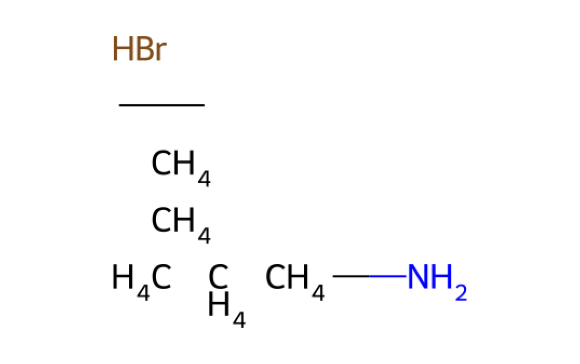

[graph 0] phase=1/4 beam_limit=2 fallback=0/3


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File "/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/joblib/__init__.py", line 115, in <module>
    from ._parallel_backends import ParallelBackendBase
  File "/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/joblib/_parallel_backends.py", line 21, in <module>
    from .executor import get_memmapping_executor
  File "/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/joblib/executor.py", line 11, in <module>
    from ._memmapping_reducer import TemporaryResourcesManager, get_memmapping_reducer

KeyboardInterrupt: 

In [50]:
generation_path = generator.generate(
    mixed_graph,
    n_edges=mixed_target_n_edges,
    draw_graphs_fn=lambda graphs: display_graphs(graphs, n_graphs_per_line=1),
)
print('n_fit_graphs =', len(fit_graphs))
print('start_n_edges =', start_graph.number_of_edges())
print('target_n_edges =', target_n_edges)
print('generation_path_length =', len(generation_path))
_ = display_graphs(generation_path, n_graphs_per_line=min(len(generation_path), 7))
_ = display_graphs([graph_a, graph_b, mixed_graph], n_graphs_per_line=2)

---